# Lesson 16 activity: feature engineering

## Notebook setup

This notebook demonstrates a common form of target leakage in feature engineering: deriving a feature directly from the label. Adding `is_censored = (MedHouseVal >= 5.0)` as a training feature improves cross-validation R² - because the model learns to look up whether the label is at the censoring cap. At inference time this flag cannot exist, so the improvement is illusory. Read the reflection section to understand what went wrong.

**Your task**: Apply at least two different feature engineering techniques to the `housing_df` dataframe to improve the dataset. At the end of the notebook, your engineered dataset and the original dataset will be used to train a linear regression model to predict `MedHouseVal`. Your goal is to achieve better model performance via feature engineering.

Don't change any of the code in the Model evaluation section of the notebook, especially the output saving. Otherwise the leaderboard scoring may not work!

Before applying transformations, explore the dataset to understand what techniques might be most beneficial.

### Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [2]:
# Load California housing dataset
original_housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
housing_df = original_housing_df.copy()

## Task 1: Explore the dataset

Before deciding what feature engineering techniques to apply, explore the dataset to understand its characteristics.

In [3]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


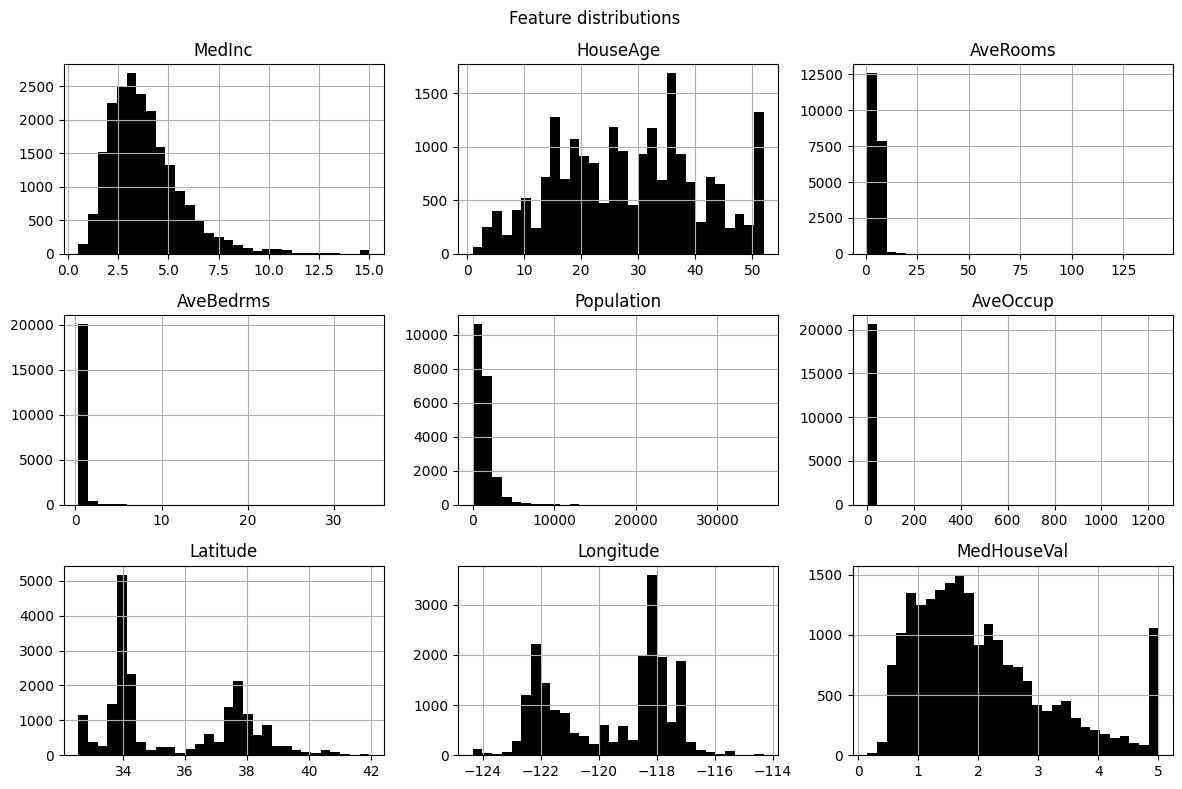

In [6]:
housing_df.hist(figsize=(12, 8), bins=30, color='black')
plt.suptitle('Feature distributions')
plt.tight_layout()
plt.show()

## Task 2: Apply your first feature engineering technique

The label `MedHouseVal` is capped at 5.0 for districts whose true median value exceeded $500K. We can identify these rows exactly: `is_censored = (MedHouseVal >= 5.0)`. Adding this as a binary feature tells the model directly which rows have an artificially clipped label - and it will learn to use that signal heavily. But the flag is a deterministic function of the label, so it can never be computed at inference time.

In [7]:
# Add a binary flag that is 1 wherever the label is at the censoring cap
housing_df['is_censored'] = (housing_df['MedHouseVal'] >= 5.0).astype(int)

n_censored = int(housing_df['is_censored'].sum())
print(f'Censored rows (MedHouseVal >= 5.0): {n_censored:,} of {len(housing_df):,} ({n_censored / len(housing_df) * 100:.1f}%)')

Censored rows (MedHouseVal >= 5.0): 992 of 20,640 (4.8%)


## Model evaluation

Now we'll compare model performance on the original dataset versus your engineered dataset.

### Evaluate datasets

In [8]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [9]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 14.65%


### Visualize model performance comparison

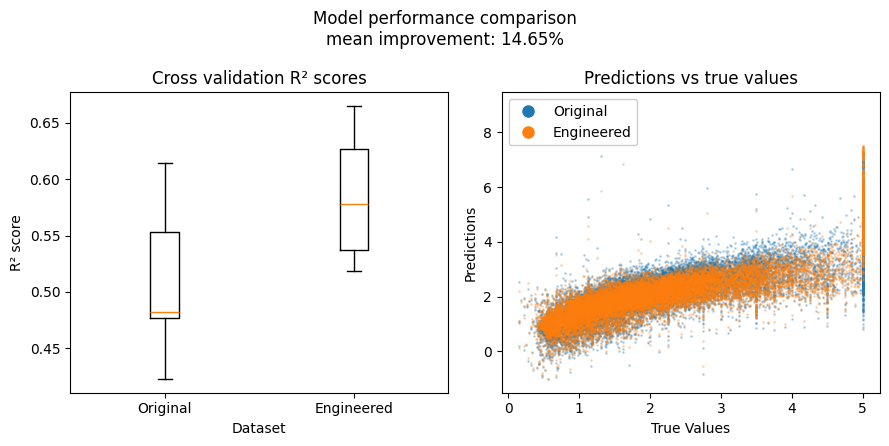

In [10]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R\u00b2 scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R\u00b2 score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

## Reflection

### What went wrong

**Target leakage**: `is_censored = (MedHouseVal >= 5.0)` is a deterministic function of the label. The model learns to use this flag as a near-perfect signal: every row where `is_censored == 1` has `MedHouseVal = 5.0`, so the prediction for those rows becomes trivially accurate. This raises R² — but the improvement disappears entirely at inference time, when the label is unknown and the flag cannot be computed.

**Why it inflates R²**: In cross-validation, each fold's test rows still have their `is_censored` value derived from the true label. The model sees a feature that perfectly encodes whether the label is at the cap, so it never has to predict that region from features alone. The score measures how well the model can look up the answer, not how well it generalises.

**The tell**: Remove `is_censored` from the feature set and re-run CV — R² will drop back to the original baseline. The gap between those two scores is entirely explained by the leaked label information.

**Why this is different from the OOF approach**: A model that predicts the *probability* a row is censored using only input features (income, location, etc.) captures the same signal without leakage — because that probability can be computed from features that genuinely exist at inference time. The OOF `p_censored` approach in the main activity solution does this correctly; using the label directly does not.